## Predecting Sunday Newspaper Circulation Based on Weekly Newspaper Circulation

## Problem Statement :

- **Design and implement simple linear regression model to predict sunday newspaper circulation based on daily newspaper circulation**
- **Predict sunday newspaper circulation for 200, 300 and 500 daily circulation**
- **Evaluate model with R-square and Adjusted R-Square**

## Import Data Set

In [22]:
import pandas as pd

df_news = pd.read_csv("NewspaperData.csv")
df_news.head()

,Newspaper,daily,sunday
0,Baltimore Sun,391.952,488.506
1,Boston Globe,516.981,798.298
2,Boston Herald,355.628,235.084
3,Charlotte Observer,238.555,299.451
4,Chicago Sun Times,537.780,559.093


In [23]:
df_news.shape

(34, 3)

In [24]:
df_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Newspaper  34 non-null     object 
 1   daily      34 non-null     float64
 2   sunday     34 non-null     float64
dtypes: float64(2), object(1)
memory usage: 948.0+ bytes


## Correlation

In [25]:
df_news[['daily','sunday']].corr()

,daily,sunday
daily,1.000000,0.958154
sunday,0.958154,1.000000


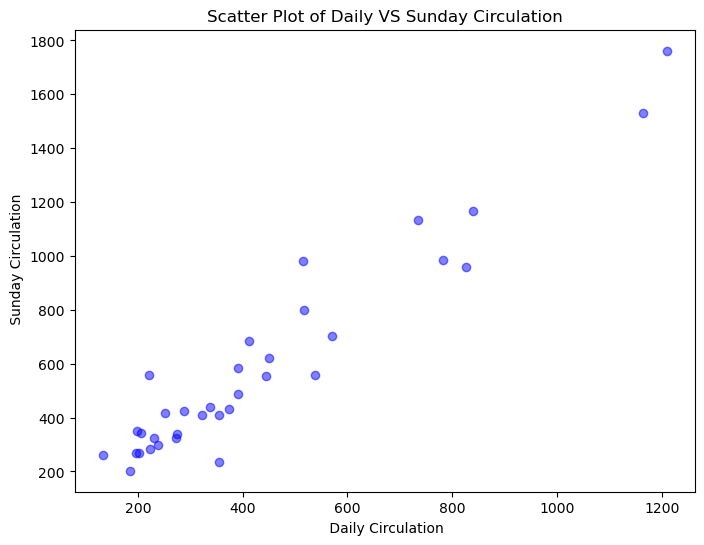

In [26]:
import matplotlib.pyplot as plt

# Extracting daily and Sunday Circulation data

daily_data = df_news['daily']
sunday_data = df_news['sunday']

#Plotting scatter plot

plt.figure(figsize=(8,6))
plt.scatter(daily_data, sunday_data, color = 'blue', alpha = 0.5)
plt.title("Scatter Plot of Daily VS Sunday Circulation")
plt.xlabel(" Daily Circulation")
plt.ylabel(" Sunday Circulation")
plt.show()

## Fitting Linear Regression Model

In [27]:
df_news= df_news.drop(columns = "Newspaper", axis = 1)
df_news.head()

,daily,sunday
0,391.952,488.506
1,516.981,798.298
2,355.628,235.084
3,238.555,299.451
4,537.780,559.093


In [29]:
import statsmodels.formula.api as smf

model = smf.ols("sunday~daily", data = df_news).fit()

In [30]:
model.params

Intercept    13.835630
daily         1.339715
dtype: float64

## T and P values

In [32]:
print(f"model t-values:\n {model.tvalues} \n ---------------------------\nmodel p-values:\n {model.pvalues}")

model t-values:
 Intercept     0.386427
daily        18.934840
dtype: float64 
 ---------------------------
model p-values:
 Intercept    7.017382e-01
daily        6.016802e-19
dtype: float64


**To sumarize if p-value for any feature(variable) is < 0.05, that variable is important and suggest not drop from dataset**

In [33]:
#Coefficient
model.params

Intercept    13.835630
daily         1.339715
dtype: float64

In [34]:
# To predict for 200 daily circulation
(1.339715*200)+13.835630

281.77862999999996

In [35]:
# To predict for 300 daily circulation
(1.339715*300)+13.835630

415.75012999999996

In [36]:
# To predict for 500 daily circulation
(1.339715*500)+13.835630

683.69313

In [37]:
# R-squared and R-squared ajusted

(model.rsquared, model.rsquared_adj)

(np.float64(0.9180596895873294), np.float64(0.9154990548869335))

In [38]:
newdata = pd.Series([200,300,500])

In [39]:
newdata

0    200
1    300
2    500
dtype: int64

In [41]:
data_pred = pd.DataFrame(newdata, columns=["daily"])

In [42]:
data_pred

,daily
0,200
1,300
2,500


In [43]:
model.predict(data_pred)

0    281.778581
1    415.750057
2    683.693009
dtype: float64

In [44]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 sunday   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     358.5
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           6.02e-19
Time:                        15:00:28   Log-Likelihood:                -206.85
No. Observations:                  34   AIC:                             417.7
Df Residuals:                      32   BIC:                             420.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.8356     35.804      0.386      0.702     -59.095      86.766
daily          1.3397      0.071     18.935      0.000       1.196       1.484
==============================================================================
Omnibus:                        3.297   Durbin-Watson:                   2.059
Prob(Omnibus):                  0.192   Jarque-Bera (JB):                1.990
Skew:                           0.396   Prob(JB):                        0.370
Kurtosis:                       3.882   Cond. No.                         965.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""